In [2]:
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from textstat import flesch_reading_ease, flesch_kincaid_grade

c:\Users\anush\anaconda3main\envs\steering\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True
)

model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 453/453 [00:04<00:00, 103.03it/s, Materializing param=model.layers.31.self_attn.v_proj.weight]
Some parameters are on the meta device because they were offloaded to the cpu.


PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): LayerNorm((2560,), eps=1

In [4]:
v_explanation = np.load("v_explanation.npy")

v_torch = torch.tensor(v_explanation, dtype=torch.float16).to("cuda")

print("Vector loaded:", v_torch.shape)

Vector loaded: torch.Size([2560])


In [ ]:
def make_hook(alpha):
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
            rest = output[1:]
            steered = hidden_states - alpha * v_scaled
            return (steered, *rest)
        else:
            return output - alpha * v_scaled
    return hook

In [6]:
def generate_with_steering(prompt, alpha=0.0, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    hook = model.model.layers[16].register_forward_hook(make_hook(alpha))

    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.8,
                top_p=0.9,
                use_cache=True
            )
    finally:
        hook.remove()

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [7]:
def readability(text):
    return (
        flesch_reading_ease(text),
        flesch_kincaid_grade(text)
    )

In [10]:
prompt = "Write a paragraph explaining how black holes work."

for a in [-2, 0, 2]:
    print(f"\n=== Alpha {a} ===")
    text = generate_with_steering(prompt, alpha=a)
    print(text[:500])  # print first 500 chars only
    
    fre, fk = readability(text)
    print(f"FRE: {fre:.2f}, FKGL: {fk:.2f}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



=== Alpha -2 ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Write a paragraph explaining how black holes work.

Answer:
Black holes are incredibly dense objects that form when a star dies and its core collapses. They are so massive that not even light can escape their gravitational pull. The event horizon, a boundary surrounding the black hole, marks the point of no return. Anything that crosses the event horizon is forever trapped within the black hole's grasp.

Exercise 2:
Imagine you are an astronaut exploring a black hole. Describe what you might see
FRE: 60.80, FKGL: 8.22

=== Alpha 0 ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Write a paragraph explaining how black holes work. Use at least three examples from the text to support your answer.

Answer:
Black holes are regions of space where gravity is so strong that nothing can escape from them. This is because they have a huge amount of mass in a very small space. For example, the text mentions that black holes form from the collapse of massive stars, where the star's core becomes so dense that it collapses into a black hole. Another example is that black holes can als
FRE: 67.20, FKGL: 8.33

=== Alpha 2 ===
Write a paragraph explaining how black holes work. Use examples from daily life, such as a hair dryer or a blender, to help illustrate your points.

Solution:
Black holes are one of the most mysterious and fascinating objects in the universe. They are formed when a massive star dies and its core collapses in on itself, creating an incredibly dense object with a gravitational pull so strong that nothing, not even light, can escape. To understand how black 

In [11]:
# check magnitude of steering vector
print("||v||:", torch.norm(v_torch).item())

# check hidden state magnitude for one example
inputs = tokenizer("Test sentence.", return_tensors="pt").to("cuda")
with torch.no_grad():
    outputs = model(**inputs)

h = outputs.hidden_states[16]
print("||h|| mean:", torch.norm(h, dim=-1).mean().item())

||v||: 1.0
||h|| mean: 482.0


In [18]:
# Measure average hidden state norm at layer 16

def measure_hidden_norm(text="Test sentence for norm measurement."):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)
    h = outputs.hidden_states[16]  # (1, seq_len, 2560)
    return torch.norm(h, dim=-1).mean().item()

hidden_norm = measure_hidden_norm()
print("Hidden norm:", hidden_norm)

Hidden norm: 282.0


In [19]:
scale_fraction = 0.1  # 10% of hidden norm

v_scaled = v_torch * (hidden_norm * scale_fraction)

print("Scaled vector norm:", torch.norm(v_scaled).item())

Scaled vector norm: 28.203125


In [20]:
def make_hook(alpha):
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
            rest = output[1:]
            steered = hidden_states - alpha * v_scaled
            return (steered, *rest)
        else:
            return output - alpha * v_scaled
    return hook

In [23]:
prompt = "Write a paragraph explaining how black holes work."

for a in [-1, 0, 1]:
    print(f"\n=== Alpha {a} ===")
    text = generate_with_steering(prompt, alpha=a)
    print(text[:400])
    
    fre, fk = readability(text)
    print(f"FRE: {fre:.2f}, FKGL: {fk:.2f}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



=== Alpha -1 ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Write a paragraph explaining how black holes work.

Answer: Black holes are regions of spacetime exhibiting gravitational acceleration so strong that nothing—no particles or even electromagnetic radiation such as light—can escape from them. They form when massive stars collapse under their own gravity, leading to an extremely compact and dense state.

Conclusion:

Congratulations on completing thi
FRE: 27.82, FKGL: 13.00

=== Alpha 0 ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Write a paragraph explaining how black holes work.
Answer: Black holes are extremely dense objects that form when a massive star dies and its core collapses. They have such a strong gravitational pull that not even light can escape from them. The intense gravitational forces cause nearby matter to be pulled towards the black hole, creating a swirling disk of gas and dust known as an accretion disk
FRE: 57.54, FKGL: 10.06

=== Alpha 1 ===
Write a paragraph explaining how black holes work. Use your own words and don't copy from the internet.
Answer: A black hole is like a big hole in space that sucks everything in, even light! It's so strong that nothing can escape from it, not even you! It's very big and very dark, and it's hiding in a very big space called a galaxy. Some black holes are in the middle of our galaxy, and some are in
FRE: 81.02, FKGL: 5.61


In [24]:
prompts = [
    "Explain photosynthesis.",
    "Explain inflation in economics.",
    "Explain quantum mechanics.",
    "Explain democracy.",
    "Explain machine learning.",
    "Explain the theory of evolution.",
    "Explain how vaccines work.",
    "Explain supply and demand.",
    "Explain plate tectonics.",
    "Explain artificial intelligence."
]

In [25]:
alphas = [-1, 0, 1]

results = []

for prompt in prompts:
    print(f"\n==============================")
    print(f"Prompt: {prompt}")
    
    for a in alphas:
        text = generate_with_steering(prompt, alpha=a)
        fre, fk = readability(text)
        
        print(f"\nAlpha {a}")
        print(f"FRE: {fre:.2f}, FKGL: {fk:.2f}")
        print(text[:200])
        
        results.append({
            "prompt": prompt,
            "alpha": a,
            "fre": fre,
            "fkgl": fk
        })

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Prompt: Explain photosynthesis.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Alpha -1
FRE: 31.94, FKGL: 13.21
Explain photosynthesis.

Solution:
Photosynthesis is a biological process by which green plants, algae, and some bacteria convert sunlight, carbon dioxide, and water into glucose and oxygen. It occurs


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...


Alpha 1
FRE: 75.47, FKGL: 5.50
Explain plate tectonics. Plate tectonics is the scientific theory that describes how the Earth's surface is made up of big pieces, called plates, that move around. The plates are like puzzle pieces th

Prompt: Explain artificial intelligence.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Alpha -1
FRE: 25.71, FKGL: 13.30
Explain artificial intelligence.

Solution:
Artificial intelligence (AI) is a branch of computer science that aims to develop intelligent machines capable of performing tasks that would typically requ


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Alpha 0
FRE: 36.78, FKGL: 11.94
Explain artificial intelligence.
AI: Artificial intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. AI systems can analyze 

Alpha 1
FRE: 75.95, FKGL: 6.57
Explain artificial intelligence. The basic idea behind artificial intelligence is to use computers to do things that people can do, like learn and solve problems. But to do that, we need to teach the 


In [28]:
import re
import pandas as pd
import matplotlib.pyplot as plt

with open("results.txt", "r", encoding="utf-8") as f:
    content = f.read()

pattern = r"Alpha\s+(-?\d+)\s+FRE:\s+([\d\.]+),\s+FKGL:\s+([\d\.]+)"
matches = re.findall(pattern, content)

data = []
for alpha, fre, fkgl in matches:
    data.append({
        "alpha": int(alpha),
        "fre": float(fre),
        "fkgl": float(fkgl)
    })

df = pd.DataFrame(data)

summary = df.groupby("alpha").mean().reset_index()
print(summary)

   alpha        fre       fkgl
0     -1  23.768889  14.032222
1      0  39.762000  11.514000
2      1  72.789000   6.762000


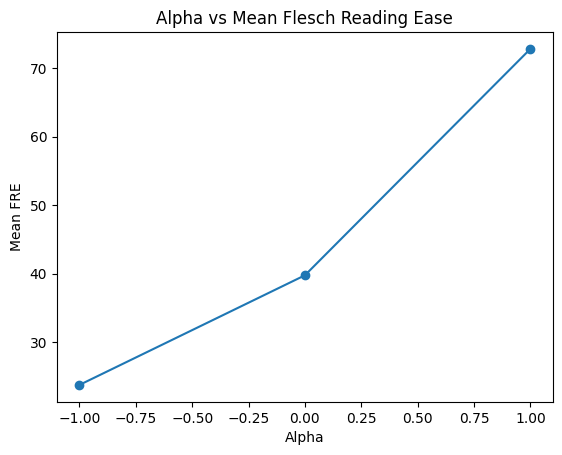

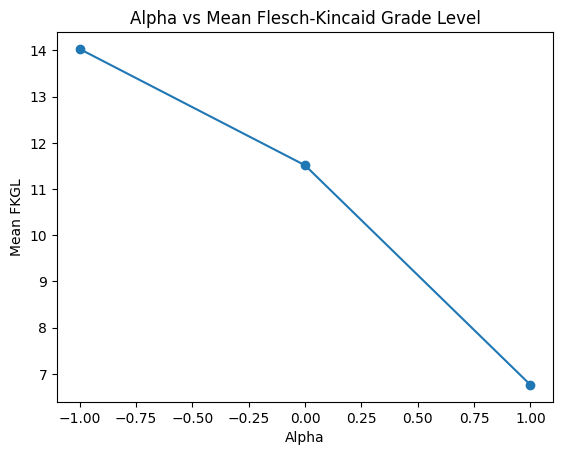

In [29]:
plt.figure()
plt.plot(summary["alpha"], summary["fre"], marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean FRE")
plt.title("Alpha vs Mean Flesch Reading Ease")
plt.show()

plt.figure()
plt.plot(summary["alpha"], summary["fkgl"], marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean FKGL")
plt.title("Alpha vs Mean Flesch-Kincaid Grade Level")
plt.show()